# 🧪 Uczenie Nadzorowane — kNN: Laboratorium

**Wymagania wstępne:** zapoznaj się z notebookiem demonstracyjnym przed przystąpieniem do zadań.

---

## 📌 Zasady

- Pracujesz na **własnym zbiorze danych** (zdyskretyzowanym, wybranym na pierwszych zajęciach)
- Klasyfikacja zawsze odbywa się na **wszystkich cechach** zbioru

---

## ⚙️ Import bibliotek i wczytanie danych

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, ShuffleSplit, cross_val_score
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
print('✅ Biblioteki załadowane')

✅ Biblioteki załadowane


In [4]:
# Wczytanie danych
df = pd.read_csv("data_discretized.csv")

DEC_COL = "UNS"
FEATURES = [col for col in df.columns if col != DEC_COL]

X = df[FEATURES].values
y = df[DEC_COL].values

print(f'Kształt zbioru: {df.shape}')
print(f'Cechy ({len(FEATURES)}): {FEATURES}')
print(f'Kolumna decyzyjna: "{DEC_COL}"')
print(f'Klasy: {sorted(df[DEC_COL].unique())}')

display(df.head())

Kształt zbioru: (403, 6)
Cechy (5): ['STG', 'SCG', 'STR', 'LPR', 'PEG']
Kolumna decyzyjna: "UNS"
Klasy: ['High', 'Low', 'Middle', 'Very Low']


,STG,SCG,STR,LPR,PEG,UNS
0,0.0,0.0,0.0,0.0,0.0,Very Low
1,0.0,0.0,0.0,0.0,3.0,High
2,0.0,0.0,0.0,1.0,1.0,Low
3,0.0,0.0,0.0,3.0,1.0,Middle
4,0.0,0.0,0.0,3.0,0.0,Low


---
# Zadanie 1 — Dobór optymalnego *k* i metryki odległości

Twoim celem jest znalezienie najlepszej kombinacji parametrów kNN:
liczby sąsiadów *k* oraz metryki odległości.

**Wymagania:**

1. Przetestuj wartości *k* ∈ {1, 3, 5, …, 29} (nieparzyste) dla każdej metryki
2. Użyj **MCCV** (ShuffleSplit, 30 iteracji, test=30%) jako metody walidacji
3. Użyj `Pipeline(MinMaxScaler + KNeighborsClassifier)` — normalizacja musi być wewnątrz CV
4. Przetestuj metryki: `euclidean`, `manhattan`, `chebyshev`
5. Dla każdej metryki wypisz: najlepsze *k*, średnią accuracy i odchylenie standardowe
6. Narysuj jeden wykres z trzema krzywymi (jedna na metrykę): oś X = k, oś Y = średnia accuracy z MCCV

> 💡 Wskazówka: `KNeighborsClassifier(n_neighbors=k, metric='manhattan')`

In [5]:

k_values = list(range(1, 30, 2))
metrics_list = ["euclidean", "manhattan", "chebyshev"]

cv_mc = ShuffleSplit(n_splits=30, test_size=0.3, random_state=RANDOM_STATE)

results = []
curves = {}

for metric in metrics_list:
    mean_scores = []
    std_scores = []

    for k in k_values:
        pipe = Pipeline([
            ("scaler", MinMaxScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k, metric=metric))
        ])

        scores = cross_val_score(pipe, X, y, cv=cv_mc, scoring="accuracy")

        mean_scores.append(scores.mean())
        std_scores.append(scores.std())

        results.append({
            "metric": metric,
            "k": k,
            "mean_acc": scores.mean(),
            "std_acc": scores.std()
        })

    curves[metric] = {
        "mean": mean_scores,
        "std": std_scores
    }

results_df = pd.DataFrame(results)

best_per_metric = results_df.loc[
    results_df.groupby("metric")["mean_acc"].idxmax()
].sort_values("mean_acc", ascending=False)

print("Najlepsze wyniki dla każdej metryki")
for _, row in best_per_metric.iterrows():
    print(
        f"Metryka: {row['metric']:10s} | "
        f"best k = {int(row['k']):2d} | "
        f"mean acc = {row['mean_acc']:.4f} | "
        f"std = {row['std_acc']:.4f}"
    )

best_row = results_df.loc[results_df["mean_acc"].idxmax()]
BEST_K = int(best_row["k"])
BEST_METRIC = best_row["metric"]

print("\n Najlepsza kombinacja globalnie ")
print(f"k = {BEST_K}")
print(f"metryka = {BEST_METRIC}")
print(f"średnia accuracy = {best_row['mean_acc']:.4f}")
print(f"odchylenie std = {best_row['std_acc']:.4f}")

Najlepsze wyniki dla każdej metryki
Metryka: manhattan  | best k = 13 | mean acc = 0.7824 | std = 0.0434
Metryka: euclidean  | best k =  9 | mean acc = 0.7656 | std = 0.0387
Metryka: chebyshev  | best k =  9 | mean acc = 0.5989 | std = 0.0377

 Najlepsza kombinacja globalnie 
k = 13
metryka = manhattan
średnia accuracy = 0.7824
odchylenie std = 0.0434


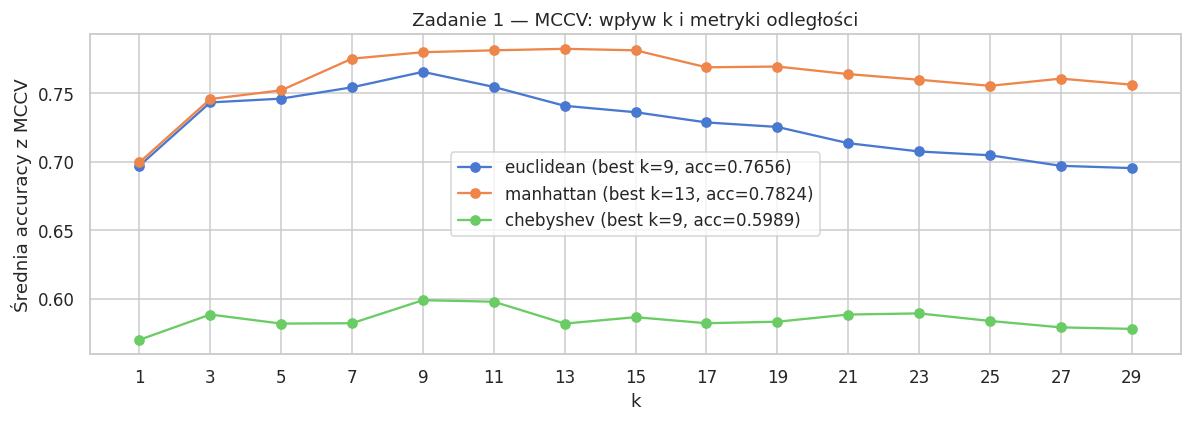

In [6]:
plt.figure(figsize=(11, 4))

for metric in metrics_list:
    mean_scores = curves[metric]["mean"]
    best_idx = int(np.argmax(mean_scores))
    plt.plot(
        k_values,
        mean_scores,
        marker='o',
        label=f"{metric} (best k={k_values[best_idx]}, acc={mean_scores[best_idx]:.4f})"
    )

plt.xlabel("k")
plt.ylabel("Średnia accuracy z MCCV")
plt.title("Zadanie 1 — MCCV: wpływ k i metryki odległości")
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

**Komentarz do Zadania 1** — odpowiedz na pytania:

1. Która metryka dała najlepsze wyniki na Twoim zbiorze?
2. Jak bardzo wyniki różnią się między metrykami? Czy różnica jest istotna?
3. Jak zachowuje się accuracy dla bardzo małego i bardzo dużego k?

1. Najlepsze wyniki uzyskała metryka Manhattan, dla której maksymalna średnia accuracy wyniosła 0.7824 przy k = 13.
Dla porównania:

- Euclidean → 0.7656 (k = 9)
- Chebyshev → 0.5989 (k = 9)

Oznacza to, że metryka Manhattan najlepiej dopasowuje się do struktury danych w tym zbiorze.

2. Różnice między metrykami są zauważalne:

- Manhattan vs Euclidean - różnica ≈ 0.017 (1.7 pp) - niewielka, ale widoczna
- Manhattan vs Chebyshev - różnica ≈ 0.183 (18.3 pp) - bardzo duża

Wniosek:

- Manhattan i Euclidean działają podobnie (ale Manhattan jest lepsza)
- Chebyshev wyraźnie się nie sprawdza w tym problemie
3. Z wykresu:

małe k (np. 1–3):
- niższa i bardziej niestabilna accuracy (~0.70)
- model jest wrażliwy na szum (overfitting)

średnie k (ok. 9–13):
- najlepsze wyniki (peak przy k = 13 dla Manhattan)

duże k (np. 21–29):
- accuracy spada
- model za bardzo uśrednia decyzje (underfitting)

Wniosek:
Optymalne są wartości pośrednie, co potwierdza wynik k = 13.

---
# Zadanie 2 — Klasyfikacja finalnym modelem i ocena wyników

Na podstawie wyników z Zadania 1 wybierz najlepszą kombinację (k + metryka)
i wytrenuj finalny model.

**Wymagania:**

1. Wybierz najlepsze *k* i metrykę z Zadania 1 — uzasadnij wybór
2. Zastosuj **K-Fold Cross-Validation** (StratifiedKFold, 5 foldów) i wypisz wyniki per fold oraz średnią
3. Wytrenuj finalny model na zbiorze treningowym (podział 70/30, stratyfikacja), oceń na testowym
4. Wyświetl **macierz pomyłek** i **raport klasyfikacji** (`classification_report`)
5. Porównaj `weights='uniform'` z `weights='distance'` dla wybranego k i metryki — który daje lepsze wyniki?

> 💡 Wskazówka: do K-Fold użyj `Pipeline` tak samo jak w Zadaniu 1.

In [7]:

pipe_best = Pipeline([
    ("scaler", MinMaxScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=BEST_K,
        metric=BEST_METRIC,
        weights="uniform"
    ))
])

cv_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_kf = cross_val_score(pipe_best, X, y, cv=cv_kf, scoring="accuracy")

print("K-Fold CV (5 foldów) ")
print("Wyniki per fold:", [f"{s:.4f}" for s in scores_kf])
print(f"Średnia: {scores_kf.mean():.4f}")
print(f"Odchylenie std: {scores_kf.std():.4f}")

K-Fold CV (5 foldów) 
Wyniki per fold: ['0.7654', '0.7778', '0.8395', '0.8125', '0.8000']
Średnia: 0.7990
Odchylenie std: 0.0261


In [8]:
# Podział 70/30 ze stratyfikacją
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train: {X_train.shape[0]} próbek")
print(f"Test:  {X_test.shape[0]} próbek")

# Finalny model
pipe_best.fit(X_train, y_train)
y_pred = pipe_best.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)

print("\n Wynik na zbiorze testowym ")
print(f"Accuracy: {test_acc:.4f}")

Train: 282 próbek
Test:  121 próbek

 Wynik na zbiorze testowym 
Accuracy: 0.7851


 Raport klasyfikacji 
              precision    recall  f1-score   support

        High       0.88      0.93      0.90        30
         Low       0.68      0.92      0.78        39
      Middle       0.89      0.65      0.75        37
    Very Low       0.78      0.47      0.58        15

    accuracy                           0.79       121
   macro avg       0.81      0.74      0.75       121
weighted avg       0.80      0.79      0.78       121



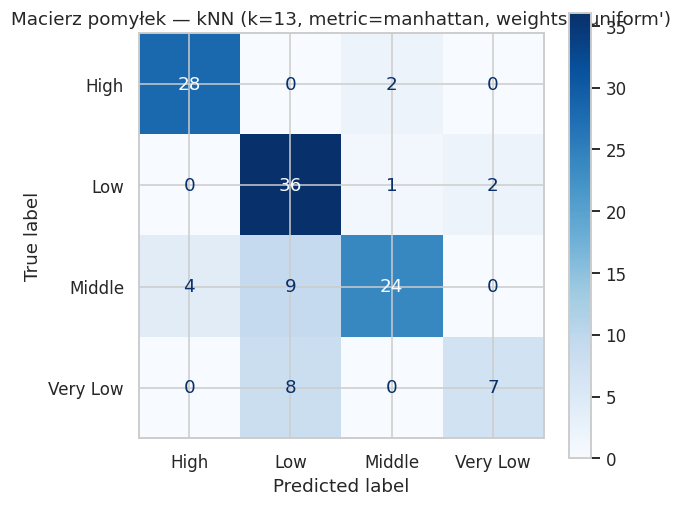

In [9]:
print(" Raport klasyfikacji ")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=ax, cmap="Blues"
)
ax.set_title(f"Macierz pomyłek — kNN (k={BEST_K}, metric={BEST_METRIC}, weights='uniform')")
plt.tight_layout()
plt.show()

In [10]:
results_weights = {}

for w in ["uniform", "distance"]:
    pipe_w = Pipeline([
        ("scaler", MinMaxScaler()),
        ("knn", KNeighborsClassifier(
            n_neighbors=BEST_K,
            metric=BEST_METRIC,
            weights=w
        ))
    ])

    pipe_w.fit(X_train, y_train)
    y_pred_w = pipe_w.predict(X_test)
    acc_w = accuracy_score(y_test, y_pred_w)

    results_weights[w] = {
        "acc": acc_w,
        "report": classification_report(y_test, y_pred_w),
        "cm": confusion_matrix(y_test, y_pred_w)
    }

print("Porównanie wag sąsiadów ")
for w, res in results_weights.items():
    print(f"weights='{w}': accuracy = {res['acc']:.4f}")

Porównanie wag sąsiadów 
weights='uniform': accuracy = 0.7851
weights='distance': accuracy = 0.8017


In [11]:
print("Raport klasyfikacji dla weights='distance'")
print(results_weights["distance"]["report"])

Raport klasyfikacji dla weights='distance'
              precision    recall  f1-score   support

        High       0.88      0.93      0.90        30
         Low       0.71      0.92      0.80        39
      Middle       0.90      0.70      0.79        37
    Very Low       0.78      0.47      0.58        15

    accuracy                           0.80       121
   macro avg       0.81      0.76      0.77       121
weighted avg       0.82      0.80      0.80       121



**Komentarz do Zadania 2** — odpowiedz na pytania:

1. Dla problemów wieloklasowych: Które klasy są najczęściej mylone? Co może być tego przyczyną?
2. Czy `weights='distance'` poprawia wyniki? Dla jakich k różnica jest największa?
3. Jak wyniki K-Fold CV mają się do wyników na zbiorze testowym?

1. Na podstawie macierzy pomyłek:

Największe błędy:

- Middle - Low (9 przypadków)
- Very Low - Low (8 przypadków)
- Middle - High (4 przypadki)

Wniosek:

- Klasa Low jest „magnesem” – wiele obserwacji z innych klas trafia właśnie do niej
- Największe pomyłki dotyczą klas:
- Middle - Low
- Very Low - Low

Przyczyna:

- klasy są blisko siebie w przestrzeni cech
- dane są zdyskretyzowane, więc różnice między klasami są mniej wyraźne
- kNN opiera się wyłącznie na odległości → podobne punkty → błędna klasyfikacja

2. Tak. Dla wybranego modelu z k = 13 i metryką manhattan wariant weights='distance' poprawił wynik na zbiorze testowym z 0.7851 do 0.8017. Oznacza to, że ważenie sąsiadów odległością w tym przypadku działa korzystnie.
3. Średni wynik z 5-fold cross-validation wyniósł 0.7990, natomiast wynik na zbiorze testowym dla modelu z weights='uniform' wyniósł 0.7851. Są to wartości zbliżone, więc model generalizuje dość stabilnie. Po zastosowaniu weights='distance' accuracy na teście wzrosło do 0.8017, co nadal pozostaje zgodne ze skalą wyników uzyskanych w walidacji krzyżowej.